In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="MDk8bq2mIrIqt8NbBzaI")
project = rf.workspace("ahmed-colnu").project("multi-class-object-detection")
version = project.version(3)
dataset = version.download("yolo26")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.8 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-s


Extracting Dataset Version Zip to Multi-Class-Object-Detection--3 in yolo26:: 100%|██████████| 3437/3437 [00:00<00:00, 7169.27it/s]


In [6]:
import os
# See the structure
for root, dirs, files in os.walk("/kaggle/working/Multi-Class-Object-Detection--3"):
    print(root, f"({len(files)} files)")

/kaggle/working/Multi-Class-Object-Detection--3 (3 files)
/kaggle/working/Multi-Class-Object-Detection--3/valid (0 files)
/kaggle/working/Multi-Class-Object-Detection--3/valid/labels (144 files)
/kaggle/working/Multi-Class-Object-Detection--3/valid/images (144 files)
/kaggle/working/Multi-Class-Object-Detection--3/test (0 files)
/kaggle/working/Multi-Class-Object-Detection--3/test/labels (72 files)
/kaggle/working/Multi-Class-Object-Detection--3/test/images (72 files)
/kaggle/working/Multi-Class-Object-Detection--3/train (0 files)
/kaggle/working/Multi-Class-Object-Detection--3/train/labels (1500 files)
/kaggle/working/Multi-Class-Object-Detection--3/train/images (1500 files)


In [7]:
import yaml
with open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml") as f:
    config = yaml.safe_load(f)
print("Classes:", config["names"])
print("Num classes:", config["nc"])

Classes: ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure']
Num classes: 4


In [8]:
import os, glob

label_dir = "/kaggle/working/Multi-Class-Object-Detection--3/train/labels"
class_counts = {0: 0, 1: 0, 2: 0, 3: 0}

for txt in glob.glob(f"{label_dir}/*.txt"):
    with open(txt) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

names = ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure']
for k, v in class_counts.items():
    print(f"{names[k]}: {v} instances")

Corrosion: 1583 instances
Cracked: 1802 instances
Efflorescence: 378 instances
Rebar Exposure: 1014 instances


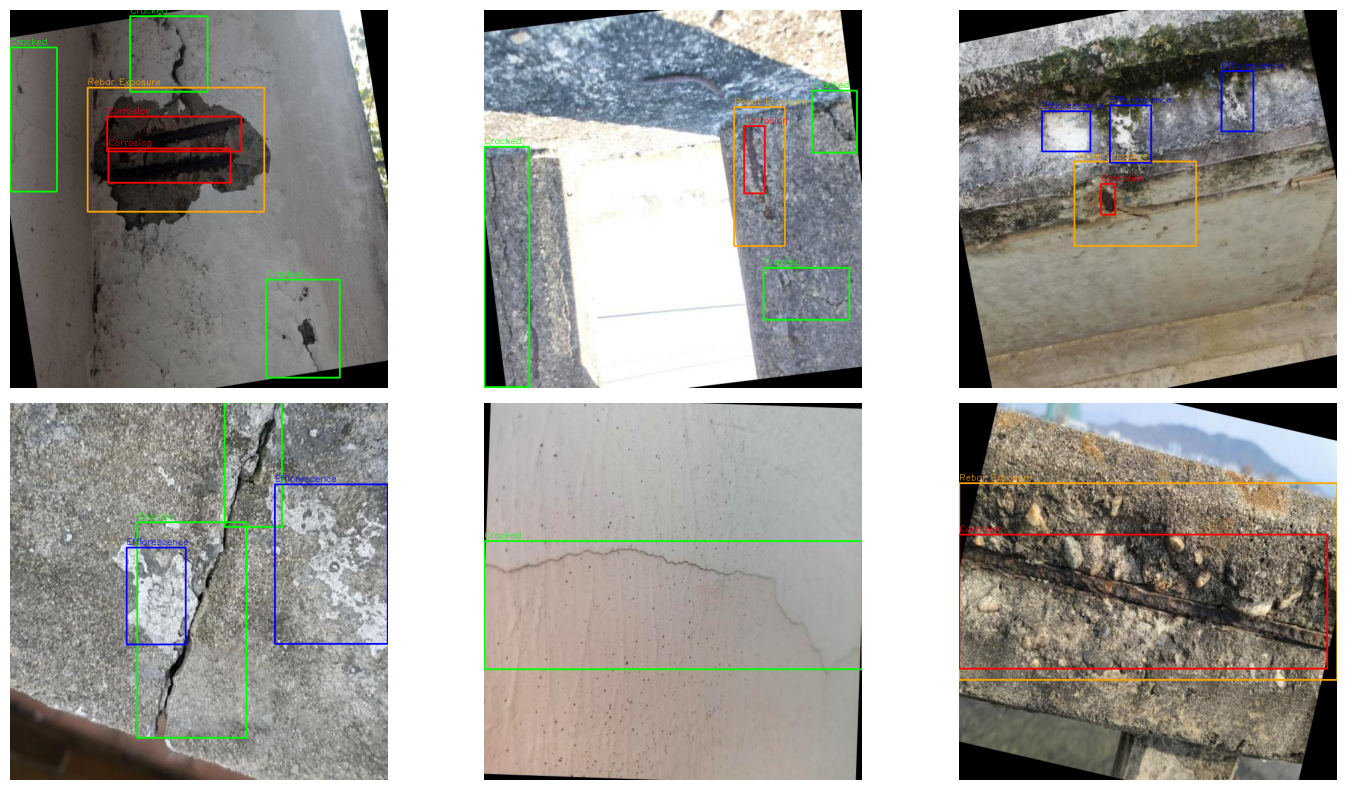

In [9]:
import cv2, matplotlib.pyplot as plt, random, glob

img_paths = glob.glob("/kaggle/working/Multi-Class-Object-Detection--3/train/images/*.jpg")
colors = [(255,0,0),(0,255,0),(0,0,255),(255,165,0)]
names = ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, random.sample(img_paths, 6)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                c, xc, yc, bw, bh = map(float, line.split())
                c = int(c)
                x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), colors[c], 2)
                cv2.putText(img, names[c], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[c], 1)
    ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

In [10]:
import cv2, os, glob
from pathlib import Path

def apply_clahe(img_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for img_path in glob.glob(f"{img_dir}/*.jpg"):
        img = cv2.imread(img_path)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = clahe.apply(l)
        merged = cv2.merge([l_clahe, a, b])
        result = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
        out_path = os.path.join(out_dir, Path(img_path).name)
        cv2.imwrite(out_path, result)

apply_clahe("/kaggle/working/Multi-Class-Object-Detection--3/train/images",
            "/kaggle/working/Multi-Class-Object-Detection--3/train/images_clahe")
apply_clahe("/kaggle/working/Multi-Class-Object-Detection--3/valid/images",
            "/kaggle/working/Multi-Class-Object-Detection--3/valid/images_clahe")

In [11]:
import shutil, glob, os

for split in ["train", "valid"]:
    label_src = f"/kaggle/working/Multi-Class-Object-Detection--3/{split}/labels"
    label_dst = f"/kaggle/working/Multi-Class-Object-Detection--3/{split}/images_clahe"
    
    for lbl in glob.glob(f"{label_src}/*.txt"):
        shutil.copy(lbl, label_dst)

print("Labels copied into images_clahe folders")

Labels copied into images_clahe folders


In [12]:
import yaml

with open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml") as f:
    config = yaml.safe_load(f)

config["train"] = "/kaggle/working/Multi-Class-Object-Detection--3/train/images_clahe"
config["val"]   = "/kaggle/working/Multi-Class-Object-Detection--3/valid/images_clahe"
config["test"]  = "/kaggle/working/Multi-Class-Object-Detection--3/test/images"

with open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml", "w") as f:
    yaml.dump(config, f)

print(yaml.safe_load(open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml")))

{'names': ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'multi-class-object-detection', 'url': 'https://universe.roboflow.com/ahmed-colnu/multi-class-object-detection/dataset/3', 'version': 3, 'workspace': 'ahmed-colnu'}, 'test': '/kaggle/working/Multi-Class-Object-Detection--3/test/images', 'train': '/kaggle/working/Multi-Class-Object-Detection--3/train/images_clahe', 'val': '/kaggle/working/Multi-Class-Object-Detection--3/valid/images_clahe'}


In [13]:
import yaml

config = {
    "path": "/kaggle/working/Multi-Class-Object-Detection--3",
    "train": "train/images_clahe",
    "val":   "valid/images_clahe",
    "test":  "test/images",
    "nc": 4,
    "names": ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure']
}
4
with open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False)

print(yaml.safe_load(open("/kaggle/working/Multi-Class-Object-Detection--3/data.yaml")))

{'names': ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure'], 'nc': 4, 'path': '/kaggle/working/Multi-Class-Object-Detection--3', 'test': 'test/images', 'train': 'train/images_clahe', 'val': 'valid/images_clahe'}


In [14]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [15]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

In [16]:
import glob, os

for f in glob.glob("/kaggle/working/Multi-Class-Object-Detection--3/**/*.cache", recursive=True):
    os.remove(f)
    print(f"Deleted: {f}")

In [17]:
model.train(
    data="/kaggle/working/Multi-Class-Object-Detection--3/data.yaml",
    epochs=100,          # was 30 — let early stopping decide
    imgsz=640,
    batch=16,
    cls=1.5,             # upweight classification — helps Efflorescence
    hsv_h=0.015,
    hsv_s=0.7,           # more saturation variation
    hsv_v=0.5,           # more brightness variation
    fliplr=0.5,
    flipud=0.3,
    degrees=45,          # more rotation
    mosaic=1.0,
    copy_paste=0.3,      # add this — synthesizes new instances
    scale=0.7,           # add this — random zoom
    save=True
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Multi-Class-Object-Detection--3/data.yaml, degrees=45, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x795394284560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [18]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [20]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")
names = ['Corrosion', 'Cracked', 'Efflorescence', 'Rebar Exposure']

metrics = model.val(data="/kaggle/working/Multi-Class-Object-Detection--3/data.yaml")

print(f"mAP@50     : {metrics.box.map50:.3f}")
print(f"mAP@50-95  : {metrics.box.map:.3f}")
print(f"Precision  : {metrics.box.mp:.3f}")
print(f"Recall     : {metrics.box.mr:.3f}")


for i, ap in enumerate(metrics.box.ap50):
    print(f"{names[i]} : {ap:.3f}")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,466,728 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2733.6±797.7 MB/s, size: 159.6 KB)
val: Scanning /kaggle/working/Multi-Class-Object-Detection--3/valid/images_clahe.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 24.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.8it/s 3.2s0.3ss
                   all        144        550      0.251       0.28       0.22     0.0782
             Corrosion         71        203      0.338      0.374      0.308      0.113
               Cracked         91        188      0.324      0.298      0.245     0.0872
         Efflorescence         15         47          0          0     0.0267     0.0111
        Rebar Exposure         72        112      0.344      0.446        0.3      0.102
Spee

In [21]:
def preprocess_clahe(img_path):
    img = cv2.imread(img_path)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

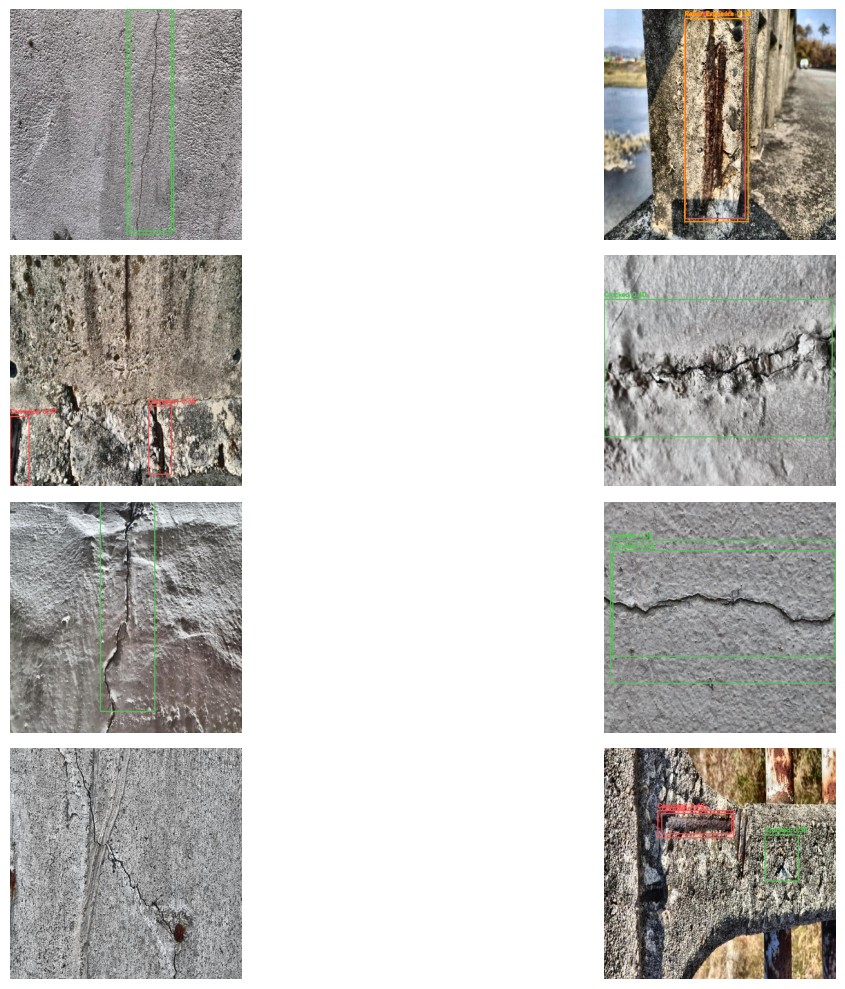

In [22]:
import glob, random, cv2, matplotlib.pyplot as plt

test_images = random.sample(glob.glob("/kaggle/working/Multi-Class-Object-Detection--3/valid/images_clahe/*.jpg"), 8)
colors = [(255,80,80), (80,200,80), (80,80,255), (255,165,0)]

fig, axes = plt.subplots(4, 2, figsize=(16, 10))

for ax, img_path in zip(axes.flat, test_images):
    img = preprocess_clahe(img_path)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    results = model.predict(img_path, conf=0.3, verbose=False)[0]

    for box in results.boxes:
        cls = int(box.cls)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(img, (x1,y1), (x2,y2), colors[cls], 2)
        cv2.putText(img, f"{names[cls]} {float(box.conf):.2f}", (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, colors[cls], 2)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
import shutil
shutil.make_archive("/kaggle/working/runs", "zip", "/kaggle/working/runs")


'/kaggle/working/runs.zip'